# Analytics Job Market in Germany

## Exploratory Data Analysis

This notebook explores the German job market for analytics-related positions using data from the Bundesagentur für Arbeit API.

The dataset has already been collected and cleaned using the ETL pipeline.

## Dataset Overview

Before starting the analysis, let's inspect the dataset structure, data types and completeness.

In [2]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/clean/jobs_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="utf-8-sig",
)

In [3]:
df.shape

(1165, 35)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                1165 non-null   str    
 1   title                 1165 non-null   str    
 2   profession            1164 non-null   str    
 3   all_professions       1164 non-null   str    
 4   company               1165 non-null   str    
 5   postal_code           1054 non-null   float64
 6   city                  1136 non-null   str    
 7   state                 1144 non-null   str    
 8   country               1165 non-null   str    
 9   latitude              1136 non-null   float64
 10  longitude             1136 non-null   float64
 11  date_posted           1165 non-null   str    
 12  date_modified         1165 non-null   str    
 13  publication_start     1165 non-null   str    
 14  start_date            1165 non-null   str    
 15  employment_type       1165 non-n

In [5]:
df.head()

,job_id,title,profession,all_professions,company,postal_code,city,state,country,latitude,...,company_url,alliance_partner,temporary_employment,private_job_agency,disability_required,salary_midpoint,has_salary,salary_yearly,salary_monthly,salary_hourly
0,12265-511279_JB5189339-S,Data Analyst (m/w/d),Data-Analyst/in,Data-Analyst/in,FERCHAU GmbH Niederlassung Kassel,34117.0,Kassel,HESSEN,DEUTSCHLAND,51.316034,...,https://www.ferchau.de,FERCHAU Engineering GmbH,True,False,False,53000.000,True,53000.0,NaN,NaN
1,12288-4876747738-S,Data Analyst (m/w/d),Data-Analyst/in,Data-Analyst/in,Liebherr-Logistics GmbH,88457.0,Kirchdorf an der Iller,BADEN_WUERTTEMBERG,DEUTSCHLAND,48.061535,...,https://www.xing.com,XING GmbH & Co. KG,False,False,False,NaN,False,NaN,NaN,NaN
2,12688-29088730-RJA-S,Data Analyst (m/w/d),Data-Analyst/in,Data-Analyst/in,WESTPRESS GmbH & Co KG,59069.0,"Hamm, Westfalen",NORDRHEIN_WESTFALEN,DEUTSCHLAND,51.623889,...,https://www.regio-jobanzeiger.de,regio-jobanzeiger.de,False,False,False,NaN,False,NaN,NaN,NaN
3,10001-1003338739-S,Analyst (m/w/d),Bankkaufmann/-frau,"Bankkaufmann/-frau, Betriebswirt/in (Fachschul...",Robert Half Deutschland - Delivery Center Stra...,60325.0,Frankfurt am Main,HESSEN,DEUTSCHLAND,50.111001,...,http://www.arbeitsagentur.de,arbeitsagentur.de,True,NaN,NaN,18.325,True,NaN,NaN,18.325
4,15220-0065535036-S,Data Analyst (m/w/d),Data-Analyst/in,Data-Analyst/in,Constaff GmbH,69115.0,"Heidelberg, Neckar",BADEN_WUERTTEMBERG,DEUTSCHLAND,49.404599,...,https://www.constaff.com,Constaff GmbH,False,False,False,NaN,False,NaN,NaN,NaN


## Research Question 1

How many analytics-related job postings are available in Germany?

In [6]:
len(df)

1165

### Finding

The dataset contains **1,165 unique job postings** after removing duplicate records.

## Research Question 2

Which German federal states have the highest demand for analytics professionals?

In [9]:
state_counts = (
    df["state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="job_count")
)

state_counts.head(10)

,state,job_count
0,NORDRHEIN_WESTFALEN,271
1,BAYERN,178
2,HESSEN,172
3,BADEN_WUERTTEMBERG,144
4,NIEDERSACHSEN,102
5,HAMBURG,73
6,BERLIN,66
7,SACHSEN,35
8,RHEINLAND_PFALZ,19
9,BREMEN,17


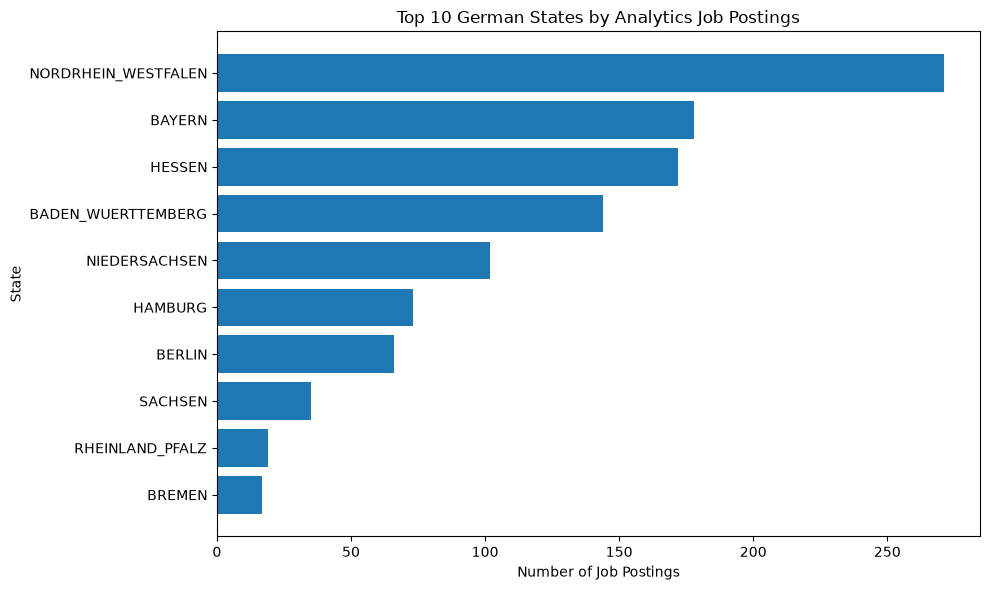

In [13]:
top_states = (
    state_counts
    .head(10)
    .sort_values("job_count")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states["state"],
    top_states["job_count"],
)

plt.title("Top 10 German States by Analytics Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("State")

plt.tight_layout()

plt.show()

### Finding

The highest demand for analytics professionals is concentrated in several economically strong German federal states.

North Rhine-Westphalia ranks first with approximately **270 job postings**, followed by Bavaria and Hessen. Together, these three states account for a substantial share of all analytics-related vacancies in the dataset.

This distribution reflects the concentration of major companies, financial institutions, manufacturing industries, and technology hubs in these regions.

## Research Question 3

Which companies publish the largest number of analytics-related job postings?

In [14]:
company_counts = (
    df["company"]
    .value_counts()
    .rename_axis("company")
    .reset_index(name="job_count")
)

company_counts.head(10)

,company,job_count
0,Finanz Informatik GmbH & Co. KG,58
1,Finanz Informatik,13
2,DIS AG Germany,12
3,alfatraining Bildungszentrum GmbH,12
4,Siemens Energy Global GmbH & Co. KG,9
5,adesta GmbH & Co. KG,8
6,prognum Automotive GmbH,8
7,Rheinmetall AG,7
8,The Quality Group Gmbh,7
9,BMW AG,7


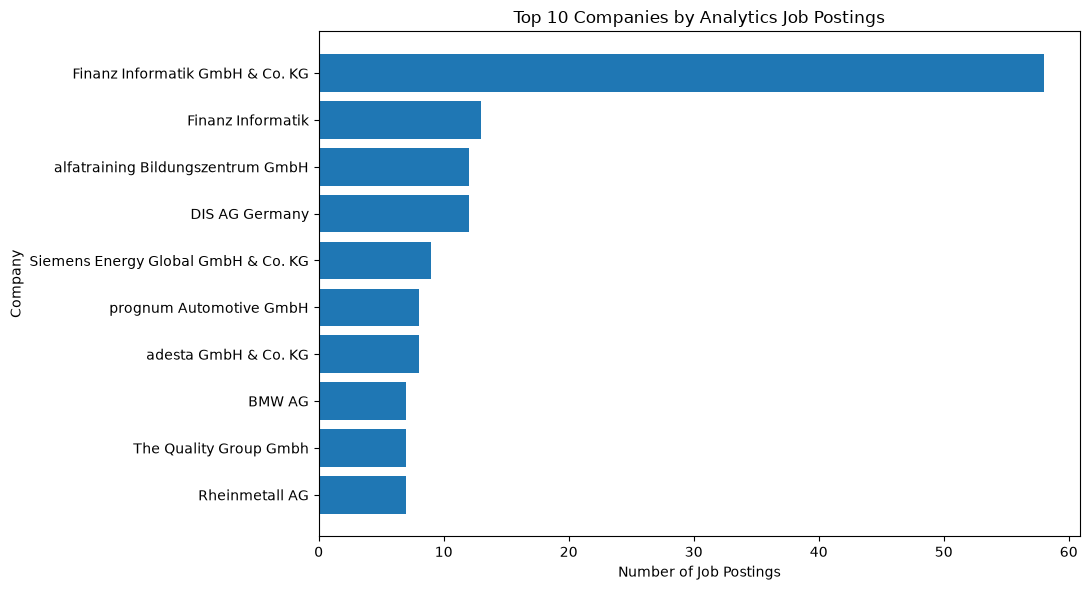

In [15]:
top_companies = (
    company_counts
    .head(10)
    .sort_values("job_count")
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_companies["company"],
    top_companies["job_count"],
)

plt.title("Top 10 Companies by Analytics Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.tight_layout()

plt.show()

### Finding

Finanz Informatik GmbH & Co. KG is the most active employer in the dataset, publishing significantly more analytics-related vacancies than any other company.

The remaining top employers include a mix of large industrial corporations, financial institutions, recruitment agencies, and training providers. This suggests that demand for analytics professionals comes from diverse sectors of the German economy rather than being concentrated in a single industry.

## Research Question 4

What salary information is available for analytics-related job postings?

In [16]:
df["has_salary"].value_counts()

has_salary
False    992
True     173
Name: count, dtype: int64

### Finding

Most job postings do not disclose salary information.

Only a relatively small share of vacancies includes explicit salary data.

In [17]:
(
    df["has_salary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

has_salary
False    85.2
True     14.8
Name: proportion, dtype: float64

In [21]:
salary = df["salary_yearly"].dropna()

In [22]:
salary = df["salary_yearly"].dropna()

salary.describe()

count       167.000000
mean      65092.785988
std       14865.840176
min       32500.000000
25%       55000.000000
50%       66000.000000
75%       75750.000000
max      105000.000000
Name: salary_yearly, dtype: float64

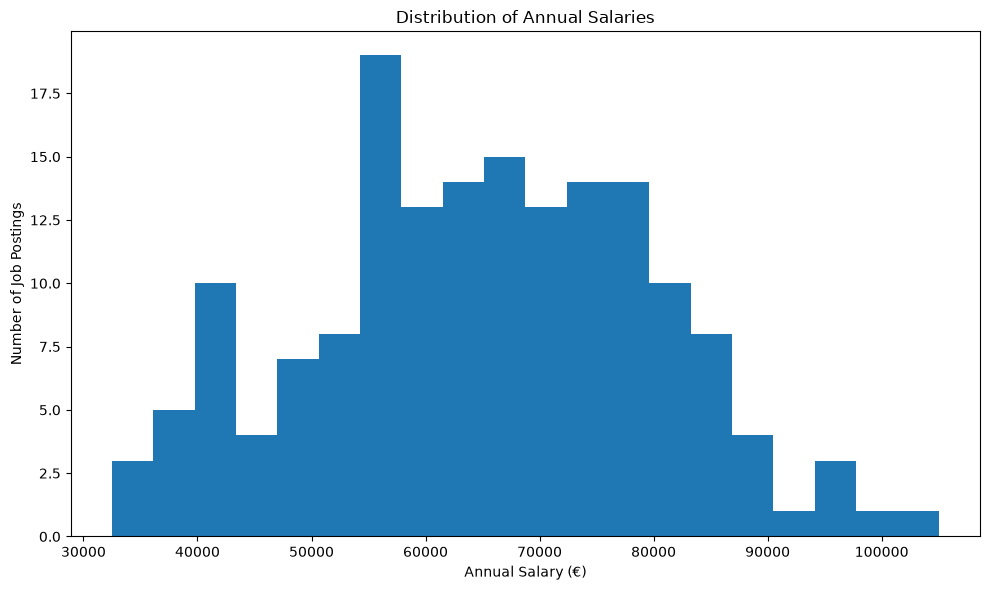

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(
    salary,
    bins=20,
)

plt.title("Distribution of Annual Salaries")
plt.xlabel("Annual Salary (€)")
plt.ylabel("Number of Job Postings")

plt.tight_layout()

plt.show()

In [24]:
salary.median()

np.float64(66000.0)

In [25]:
salary.agg(
    [
        "count",
        "min",
        "median",
        "mean",
        "max",
    ]
)

count        167.000000
min        32500.000000
median     66000.000000
mean       65092.785988
max       105000.000000
Name: salary_yearly, dtype: float64

### Finding

Only a subset of job postings provides explicit salary information. Among these vacancies, the annual salary distribution is centered around **€66,000**, which represents the median advertised salary.

Most analytics-related positions offer annual salaries between **€55,000 and €80,000**, while only a small number of vacancies exceed **€90,000** per year. This suggests that the majority of advertised roles fall within a relatively consistent salary range.

## Research Question 5

Which technical skills are most frequently mentioned in analytics job descriptions?

In [26]:
"description" in df.columns

True

In [30]:
skills = [
    "Python",
    "SQL",
    "Power BI",
    "Excel",
    "SAP",
    "Tableau",
    "Azure",
    "AWS",
    "Machine Learning",
]

In [31]:
skill_counts = {}

for skill in skills:
    skill_counts[skill] = (
        df["description"]
        .str.contains(
            skill,
            case=False,
            na=False,
        )
        .sum()
    )

skill_counts

{'Python': np.int64(159),
 'SQL': np.int64(242),
 'Power BI': np.int64(154),
 'Excel': np.int64(297),
 'SAP': np.int64(219),
 'Tableau': np.int64(57),
 'Azure': np.int64(52),
 'AWS': np.int64(26),
 'Machine Learning': np.int64(34)}

In [32]:
skills_df = (
    pd.DataFrame(
        skill_counts.items(),
        columns=["skill", "job_count"],
    )
    .sort_values(
        "job_count",
        ascending=False,
    )
)

skills_df

,skill,job_count
3,Excel,297
1,SQL,242
4,SAP,219
0,Python,159
2,Power BI,154
5,Tableau,57
6,Azure,52
8,Machine Learning,34
7,AWS,26


In [36]:
skills_plot = (
    skills_df
    .sort_values("job_count")
)

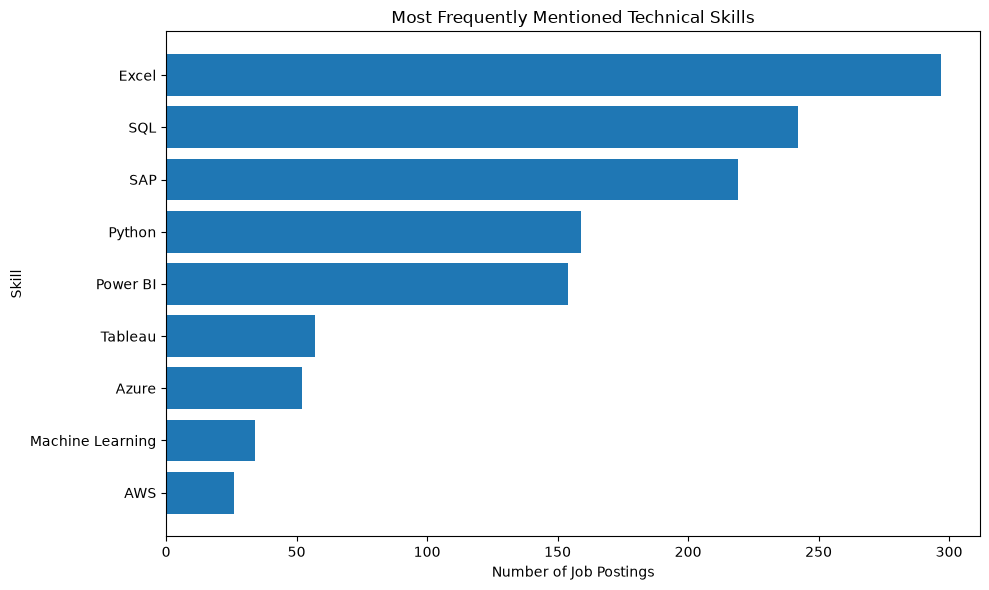

In [37]:
plt.figure(figsize=(10, 6))

plt.barh(
    skills_plot["skill"],
    skills_plot["job_count"],
)

plt.title("Most Frequently Mentioned Technical Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()

plt.show()

### Finding

Excel is the most frequently mentioned technical skill in analytics-related job postings, appearing in nearly **300 vacancies**.

SQL and SAP are also highly demanded, highlighting the importance of database management and enterprise resource planning systems in the German analytics job market.

Programming skills such as **Python** are requested in a substantial number of vacancies, while business intelligence tools like **Power BI** and **Tableau** remain important for reporting and data visualization roles.

Cloud platforms (**Azure** and **AWS**) and **Machine Learning** are mentioned less frequently, suggesting that these skills are primarily required for more specialized analytics positions rather than for general analyst roles.